# 03. Model Building & Evaluation

**Goal:** Train multiple classification models, compare performance, select the best model, analyze feature importance, and save the final model.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold

# Optional advanced models
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed. Skipping.")

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("LightGBM not installed. Skipping.")

%matplotlib inline
sns.set_palette('Set2')

## 2. Load Processed Data

In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

feature_names = joblib.load('../models/feature_names.pkl')

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train churn rate: {y_train.mean():.3f}")
print(f"y_test  churn rate: {y_test.mean():.3f}")

X_train: (5634, 37)
X_test : (1409, 37)
y_train churn rate: 0.265
y_test  churn rate: 0.265


## 3. Define Models

In [3]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

if HAS_XGB:
    models['XGBoost'] = XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()  # handle imbalance
    )

if HAS_LGBM:
    models['LightGBM'] = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42,
        class_weight='balanced',
        verbose=-1
    )

print("Models to train:", list(models.keys()))

Models to train: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM']


## 4. Train & Evaluate Models

In [4]:
results = []
trained_models = {}

for name, model in models.items():
    print(f"\n===== Training {name} =====")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })
    
    trained_models[name] = model
    
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


===== Training Logistic Regression =====


Accuracy : 0.7339
Precision: 0.4992
Recall   : 0.7941
F1-Score : 0.6130
ROC-AUC  : 0.8423

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.91      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.73      0.75      1409


===== Training Random Forest =====


Accuracy : 0.7665
Precision: 0.5522
Recall   : 0.6364
F1-Score : 0.5913
ROC-AUC  : 0.8254

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.81      0.84      1035
       Churn       0.55      0.64      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409


===== Training Gradient Boosting =====


Accuracy : 0.8027
Precision: 0.6727
Recall   : 0.5000
F1-Score : 0.5736
ROC-AUC  : 0.8442

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.91      0.87      1035
       Churn       0.67      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


===== Training XGBoost =====


Accuracy : 0.7566
Precision: 0.5289
Recall   : 0.7594
F1-Score : 0.6235
ROC-AUC  : 0.8346

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.82      1035
       Churn       0.53      0.76      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409


===== Training LightGBM =====


Accuracy : 0.7693
Precision: 0.5518
Recall   : 0.6979
F1-Score : 0.6163
ROC-AUC  : 0.8274

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1035
       Churn       0.55      0.70      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.77      0.78      1409



In [5]:
# Results comparison table
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print("\n=== Model Comparison ===")
display(results_df.style.highlight_max(axis=0, subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'], color='lightgreen'))


=== Model Comparison ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.802697,0.672662,0.500000,0.573620,0.844235
1,Logistic Regression,0.733854,0.499160,0.794118,0.613003,0.842313
2,XGBoost,0.756565,0.528864,0.759358,0.623491,0.834593
3,LightGBM,0.769340,0.551797,0.697861,0.616293,0.827383
4,Random Forest,0.766501,0.552204,0.636364,0.591304,0.825389


## 5. Visualize Model Performance

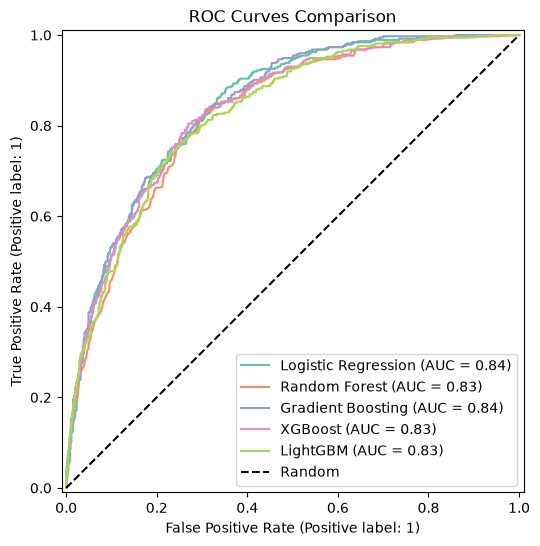

In [6]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, model in trained_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random')
ax.set_title('ROC Curves Comparison')
ax.legend()
plt.show()

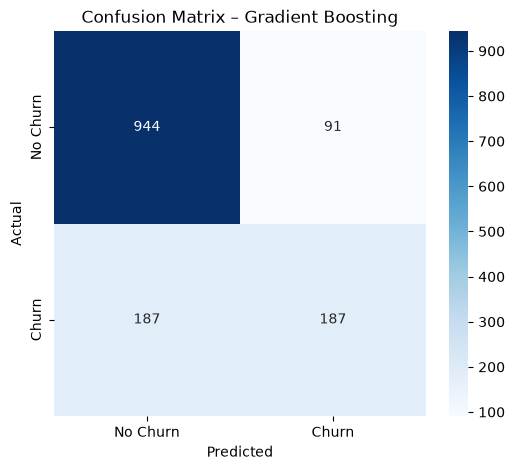

Best Model: Gradient Boosting


In [7]:
# Confusion Matrix for the best model
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix – {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"Best Model: {best_model_name}")

## 6. Feature Importance

Feature Importance – Gradient Boosting


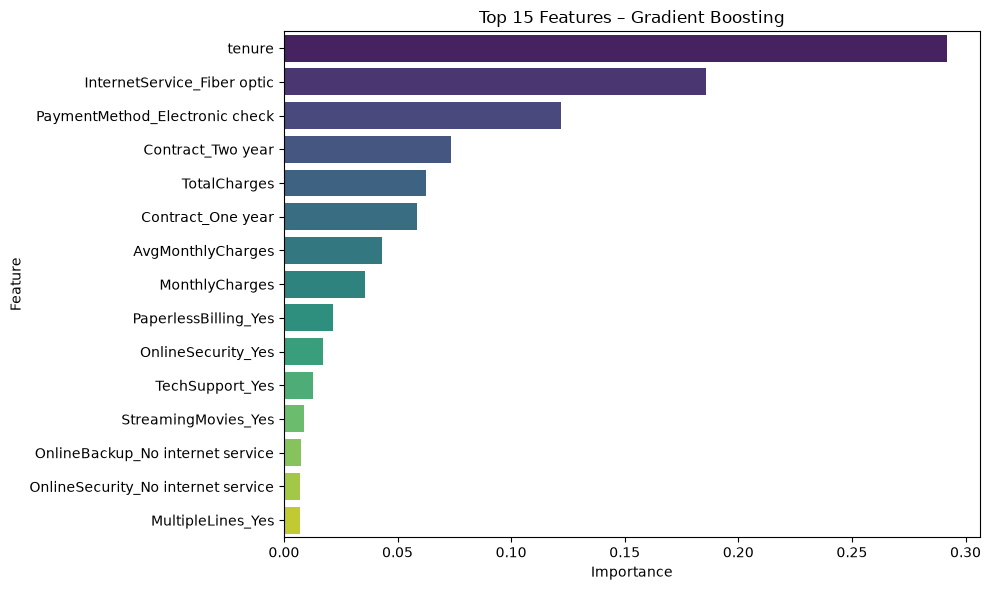

In [8]:
def plot_feature_importance(model, feature_names, top_n=15, title='Feature Importance'):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
    else:
        print("Model does not support feature importance.")
        return
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False).head(top_n)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
    plt.title(title)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    return importance_df

# Plot for best model
print(f"Feature Importance – {best_model_name}")
importance_df = plot_feature_importance(best_model, feature_names, top_n=15,
                                        title=f'Top 15 Features – {best_model_name}')

## 7. Optional: Hyperparameter Tuning (GridSearchCV)

Uncomment and run if you want better performance (takes longer).

In [9]:
# Example for Random Forest
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [5, 10, 15, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
# grid = GridSearchCV(rf, param_grid, cv=StratifiedKFold(5), scoring='roc_auc', n_jobs=-1, verbose=1)
# grid.fit(X_train, y_train)

# print("Best params:", grid.best_params_)
# print("Best CV ROC-AUC:", grid.best_score_)

# best_model = grid.best_estimator_

## 8. Optional: SHAP Explainability (Highly Recommended)

Install with: `pip install shap`

In [10]:
# try:
#     import shap
#     
#     # Use a sample for speed
#     explainer = shap.TreeExplainer(best_model) if hasattr(best_model, 'feature_importances_') else shap.Explainer(best_model, X_train)
#     shap_values = explainer.shap_values(X_test[:500])  # sample
#     
#     # Summary plot
#     shap.summary_plot(shap_values, X_test[:500], feature_names=feature_names, max_display=15)
#     
#     # For binary classification with TreeExplainer, shap_values can be a list
#     # shap.summary_plot(shap_values[1], X_test[:500], feature_names=feature_names)
#     
# except ImportError:
#     print("SHAP not installed. Run: pip install shap")
# except Exception as e:
#     print(f"SHAP error: {e}")

## 9. Save the Best Model

In [11]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(results_df, '../models/model_comparison.pkl')

print(f"Best model ({best_model_name}) saved to ../models/best_model.pkl")
print("Model comparison table saved.")

Best model (Gradient Boosting) saved to ../models/best_model.pkl
Model comparison table saved.


### Summary of Model Performance

Fill this after running:

| Model | ROC-AUC | F1 | Recall | Notes |
|-------|---------|----|--------|-------|
| ... | ... | ... | ... | Best overall |

**Recommendation:** Prefer higher **Recall** if the business cost of missing a churner is high (common in telecom).

### Next Steps
→ Go to **04_insights_recommendations.ipynb**